# Intraday MA Crossover Query Backtest

This notebook fetches intraday `IRS_RATE` data for `USD-SOFR-1D-Q12STIRT` / `IMM_4xIMM_5`, builds a simple moving-average crossover signal, runs a quick vectorized sanity check, and then runs the canonical `QueryDrivenBacktest` implementation.

The trade query uses `market_request={"timestamp": "now"}` so the query-driven run requests true intraday curves. For `BARCHART_STIRF-RL`, single-request pricing now consults CurveStore before falling back to a fresh curve build.


In [1]:
%load_ext autoreload
%autoreload 2

import datetime
import sys

import matplotlib.pyplot as plt
import pandas as pd
import pytz

sys.path.append("../../")

from BT.signals import moving_average_crossover_signal, run_technical_indicator_query_backtest
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from Query.IRSwaps.IRSwapQuery import IRSwapQuery
from Query.IRSwaps.IRSwapValue import IRSwapValue
from Query.Unified.UnifiedQuery import UnifiedQuery
from Query.Unified.registry import UnifiedValue
from TB.TimeseriesBuilder import TimeseriesBuilder

NYC = pytz.timezone("America/New_York")


In [2]:
curve_mdp = IRSwapsMDP(source="BARCHART_STIRF-RL")
ts_builder = TimeseriesBuilder()
trade_bpv = 100_000.0

start = NYC.localize(datetime.datetime(2026, 1, 4, 18, 0))
end = NYC.localize(datetime.datetime(2026, 3, 27, 17, 0))

q = UnifiedQuery(
    curve="USD-SOFR-1D-Q12STIRT",
    tenor="IMM_4xIMM_5",
    value=UnifiedValue.IRS_RATE,
)

intraday_df = ts_builder.get_timeseries(
    start=start,
    end=end,
    queries=[q],
    freq="1min",
    mdps={"IRS": curve_mdp},
    ignore_cache_miss=True,
)
intraday_df = intraday_df.sort_index()

rate_series = pd.to_numeric(intraday_df.iloc[:, 0], errors="coerce").dropna()
rate_series = rate_series.resample("1min").last().dropna()
rate_series.name = "IMM_4xIMM_5"

rate_series

Date
2026-01-04 18:00:00-05:00    3.119813
2026-01-04 18:01:00-05:00    3.119793
2026-01-04 18:02:00-05:00    3.116991
2026-01-04 18:03:00-05:00    3.115780
2026-01-04 18:04:00-05:00    3.115950
                               ...   
2026-03-27 16:56:00-04:00    3.746166
2026-03-27 16:57:00-04:00    3.747444
2026-03-27 16:58:00-04:00    3.748512
2026-03-27 16:59:00-04:00    3.747259
2026-03-27 17:00:00-04:00    3.747259
Name: IMM_4xIMM_5, Length: 79258, dtype: float64

In [3]:
signal_result = moving_average_crossover_signal(
    rate_series,
    fast_window=60,
    slow_window=120,
)

display(signal_result.indicator_frame.tail())
display(
    pd.DataFrame(
        {
            "rate": signal_result.raw_series,
            "desired_position": signal_result.desired_position,
            "execution_position": signal_result.execution_position,
        }
    ).tail()
)


,fast_ma,slow_ma,spread
Date,,,
2026-03-27 16:56:00-04:00,3.743208,3.742907,0.000301
2026-03-27 16:57:00-04:00,3.743405,3.742907,0.000498
2026-03-27 16:58:00-04:00,3.743621,3.742926,0.000695
2026-03-27 16:59:00-04:00,3.743771,3.742936,0.000835
2026-03-27 17:00:00-04:00,3.743920,3.742959,0.000961


,rate,desired_position,execution_position
Date,,,
2026-03-27 16:56:00-04:00,3.746166,1.0,1.0
2026-03-27 16:57:00-04:00,3.747444,1.0,1.0
2026-03-27 16:58:00-04:00,3.748512,1.0,1.0
2026-03-27 16:59:00-04:00,3.747259,1.0,1.0
2026-03-27 17:00:00-04:00,3.747259,1.0,1.0


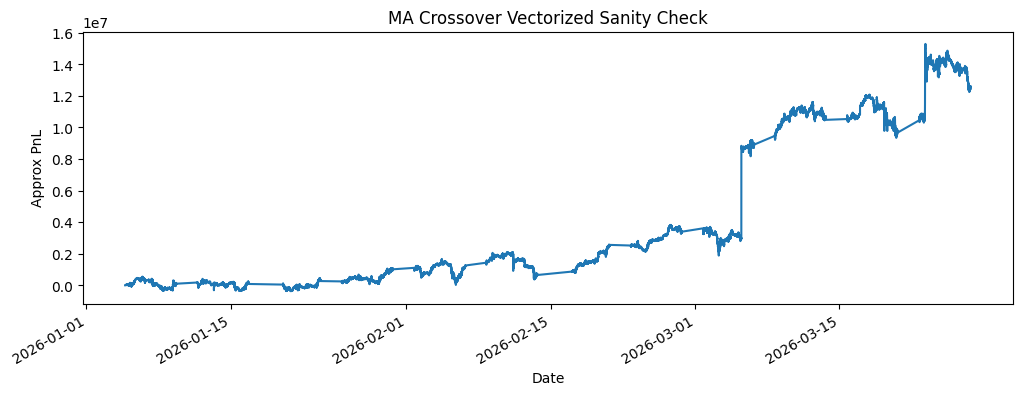

In [4]:
# Vectorized sanity check only. The canonical result is the query-driven backtest below.
vectorized_position = signal_result.execution_position.fillna(0.0)
vectorized_pnl = -vectorized_position * rate_series.diff().fillna(0.0) * trade_bpv * 100.0
vectorized_cumulative_pnl = vectorized_pnl.cumsum()

fig, ax = plt.subplots(figsize=(12, 4))
vectorized_cumulative_pnl.plot(ax=ax, title="MA Crossover Vectorized Sanity Check")
ax.set_ylabel("Approx PnL")
plt.show()


In [18]:
# Keep timestamp="now" so the query-driven backtest requests true intraday curves.
# For BARCHART_STIRF-RL, single-request pricing consults CurveStore first.
def trade_query_factory(target_position, now, info):
    _ = now, info
    return IRSwapQuery(
        curve="USD-SOFR-1D-Q12STIRT",
        tenor="IMM_4xIMM_5",
        value=IRSwapValue.NPV,
        market_request={"timestamp": "now"},
        structure_kwargs={"bpv": trade_bpv * float(target_position)},
        tags=("intraday_ma_crossover_q12stirt",),
    )


query_backtest = run_technical_indicator_query_backtest(
    signal_result,
    trade_query_factory=trade_query_factory,
    mdp=curve_mdp,
    strategy_name="intraday_ma_crossover_q12stirt",
    ignore_cache_miss=True,
    show_progress=True,
)

query_backtest.metrics


KeyboardInterrupt: 

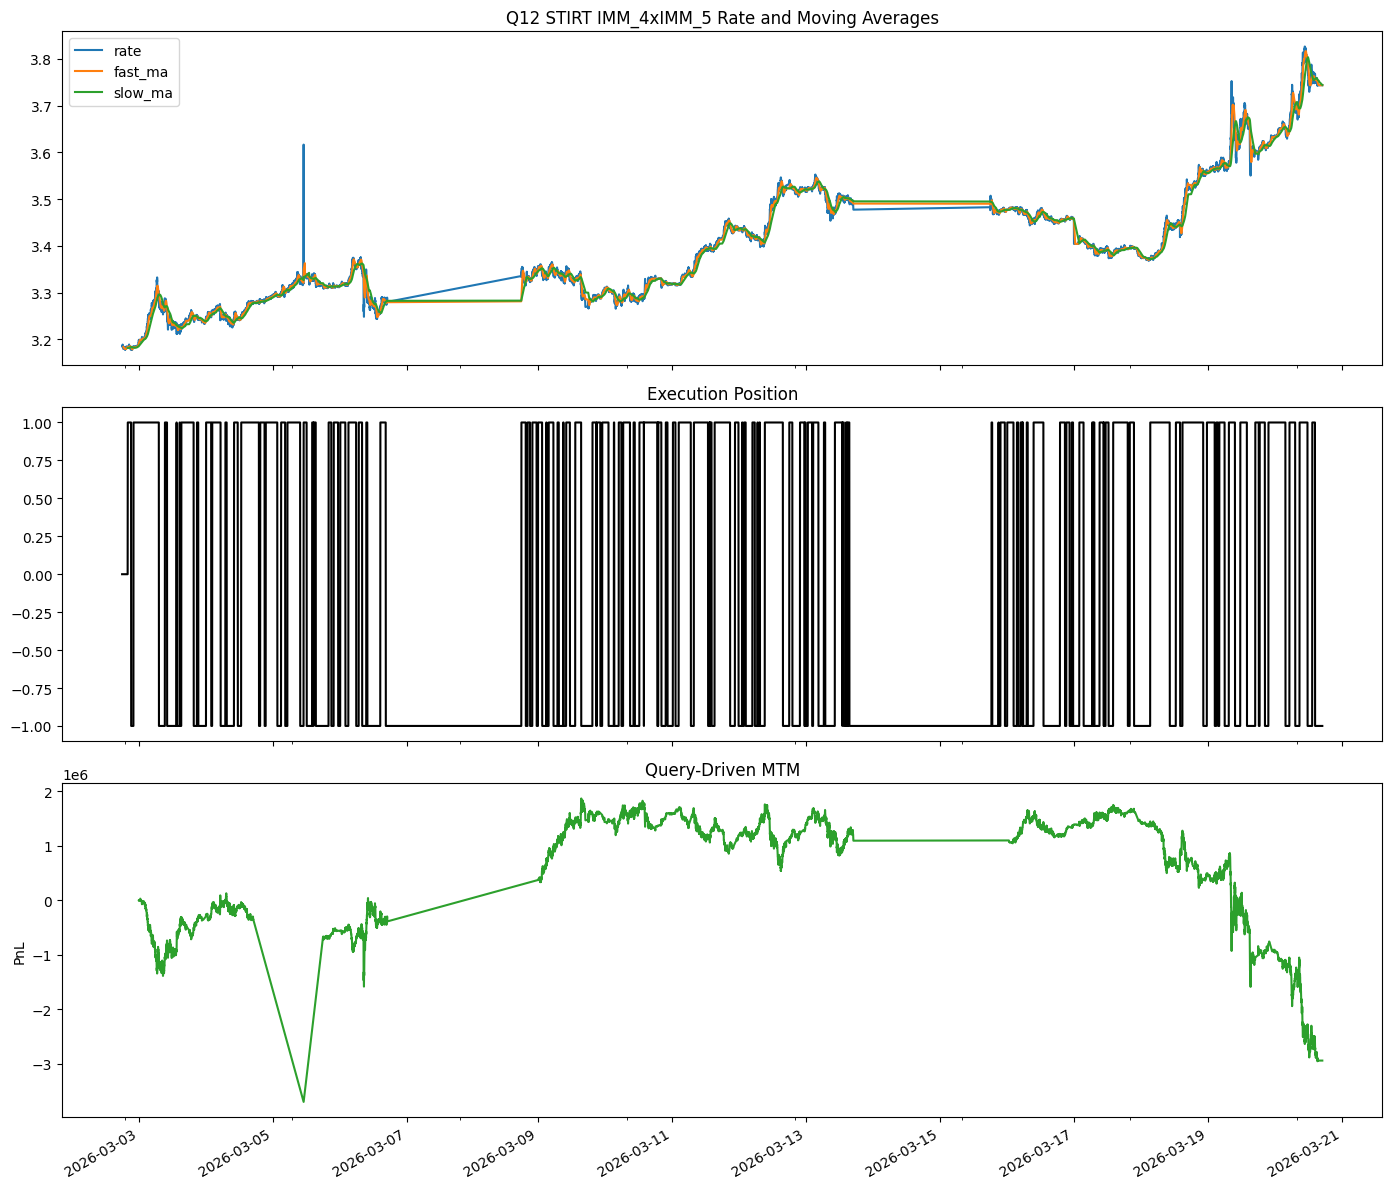

,timestamp,signal_key,raw_signal_key,position_id,signal_direction,order_type
185,2026-03-20 07:17:00-04:00,IMM_4xIMM_5,IMM_4xIMM_5,IMM_4xIMM_5|2026-03-20T07:17:00-04:00|186|leg1,-1,QueryOrder
186,2026-03-20 08:50:00-04:00,IMM_4xIMM_5,IMM_4xIMM_5,IMM_4xIMM_5|2026-03-20T08:50:00-04:00|187|leg1,1,QueryOrder
187,2026-03-20 11:42:00-04:00,IMM_4xIMM_5,IMM_4xIMM_5,IMM_4xIMM_5|2026-03-20T11:42:00-04:00|188|leg1,-1,QueryOrder
188,2026-03-20 13:23:00-04:00,IMM_4xIMM_5,IMM_4xIMM_5,IMM_4xIMM_5|2026-03-20T13:23:00-04:00|189|leg1,1,QueryOrder
189,2026-03-20 14:23:00-04:00,IMM_4xIMM_5,IMM_4xIMM_5,IMM_4xIMM_5|2026-03-20T14:23:00-04:00|190|leg1,-1,QueryOrder


In [8]:
plot_df = pd.DataFrame(
    {
        "rate": signal_result.raw_series,
        "fast_ma": signal_result.indicator_frame["fast_ma"],
        "slow_ma": signal_result.indicator_frame["slow_ma"],
        "execution_position": signal_result.execution_position,
    }
).dropna(subset=["rate"])

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
plot_df[["rate", "fast_ma", "slow_ma"]].plot(ax=axes[0], title="Q12 STIRT IMM_4xIMM_5 Rate and Moving Averages")
plot_df["execution_position"].fillna(0.0).plot(ax=axes[1], title="Execution Position", color="black")
query_backtest.mtm_history.plot(ax=axes[2], title="Query-Driven MTM", color="tab:green")
axes[2].set_ylabel("PnL")
plt.tight_layout()
plt.show()

query_backtest.order_frame.tail()
